# Feature scaling and encoding categorical variables

### Getting the columns into a shape the model can actually read

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Which models need scaling and which cannot tell the difference, what the four scalers do to a column with a long tail, why ordinal encoding invents an order that was never in the data, and how target encoding leaks the answer if you compute it in the wrong place |
| **You should already know** | [Cross-validation](../04-cross-validation/), [k-nearest neighbours](../../03-classification/02-k-nearest-neighbours/), [linear regression](../../02-regression/01-linear-regression/) |
| **Datasets** | UCI Dry Bean, UCI Bike Sharing |
| **Runtime** | Under two minutes on a laptop CPU |
| **Next** | [01-08 Missing data](../08-missing-data/) |

---

## 1. Why scale at all

A model does not know what a column means. It sees numbers. If one column runs
to six figures and another sits near a thousandth, any method that measures a
distance, or takes a step down a gradient, is going to be governed almost
entirely by the big column, and that has nothing to do with which column
carries the signal.

The Dry Bean data makes this concrete. It is a set of shape measurements taken
from photographs of grains. `Area` is a raw pixel count. `ShapeFactor2` is a
small ratio. Both describe the same bean, and they are nowhere near the same
size.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

In [2]:
from sklearn.preprocessing import StandardScaler

X_bean, y_bean = datasets.dry_bean()

spread = pd.DataFrame({
    "min": X_bean.min(),
    "median": X_bean.median(),
    "max": X_bean.max(),
    "std": X_bean.std(),
}).sort_values("std", ascending=False)

print(spread.to_string(float_format=lambda v: f"{v:>12,.4g}"))
print(f"\nlargest std / smallest std: {spread['std'].max() / spread['std'].min():,.0f}x")

                         min       median          max          std
ConvexArea         2.068e+04    4.518e+04    2.633e+05    2.977e+04
Area               2.042e+04    4.465e+04    2.546e+05    2.932e+04
Perimeter              524.7        794.9        1,985        214.3
MajorAxisLength        183.6        296.9        738.9        85.69
EquivDiameter          161.2        238.4        569.4        59.18
MinorAxisLength        122.5        192.4        460.2        44.97
AspectRation           1.025        1.551         2.43       0.2467
ShapeFactor3          0.4103        0.642       0.9748        0.099
Eccentricity           0.219       0.7644       0.9114        0.092
Compactness           0.6406       0.8013       0.9873      0.06171
roundness             0.4896       0.8832       0.9907      0.05952
Extent                0.5553       0.7599       0.8662      0.04909
Solidity              0.9192       0.9883       0.9947      0.00466
ShapeFactor4          0.9477       0.9964       

The printed ratio between the widest column and the narrowest runs to many
orders of magnitude. Now the part that matters: how much does each column
actually contribute to the distance between two beans?

I take four thousand random pairs of rows, square the per-column gap, and ask
what share of the total squared distance each column accounts for. Once
before scaling, once after.

In [3]:
rng = np.random.default_rng(SEED)
pairs = rng.choice(len(X_bean), (4000, 2))

gap_raw = (X_bean.values[pairs[:, 0]] - X_bean.values[pairs[:, 1]]) ** 2
share_raw = pd.Series(gap_raw.mean(axis=0) / gap_raw.mean(axis=0).sum(), index=X_bean.columns)

Z = StandardScaler().fit_transform(X_bean.values)
gap_std = (Z[pairs[:, 0]] - Z[pairs[:, 1]]) ** 2
share_std = pd.Series(gap_std.mean(axis=0) / gap_std.mean(axis=0).sum(), index=X_bean.columns)

top = share_raw.sort_values(ascending=False)
print("share of squared Euclidean distance, raw columns")
for name in top.index[:3]:
    print(f"  {name:18} {top[name]:8.4%}")
print(f"  the other {len(top) - 3} columns together: {top.iloc[3:].sum():.4%}")

print("\nshare after StandardScaler")
print(f"  largest  : {share_std.idxmax():18} {share_std.max():.4%}")
print(f"  smallest : {share_std.idxmin():18} {share_std.min():.4%}")
print(f"  an equal split of 16 columns would be {1 / len(share_std):.4%}")

share of squared Euclidean distance, raw columns
  ConvexArea         50.7632%
  Area               49.2335%
  Perimeter           0.0026%
  the other 13 columns together: 0.0007%

share after StandardScaler
  largest  : MinorAxisLength    6.4743%
  smallest : ShapeFactor4       5.8836%
  an equal split of 16 columns would be 6.2500%


A pair of columns accounts for essentially all of the distance, and everything
else divides up what is left of a rounding error. `Area` and `ConvexArea` are
close to the same measurement, so a nearest-neighbour search on the raw table
is a search on bean size and nothing else. Every ratio, every shape factor,
every eccentricity: all of it is ignored.

After standardising, every column lands within a whisker of an equal share.
That is what scaling buys: the model gets to decide which columns
matter, instead of the units deciding for it.

## 2. Which models care, measured

The usual advice is "trees do not need scaling, everything else does". I want
to see the size of the effect rather than take it on faith, so I run the same
seven-class bean problem through five model families twice (once on the raw
table, once with a `StandardScaler` in front) and compare cross-validated
accuracy.

The support vector machine is quadratic in the number of rows, so I take a
stratified sample of three thousand beans and give every model the same rows.

In [4]:
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

# unscaled logistic regression will not converge in 1000 iterations. That is the
# finding, not an accident, so the warning is silenced and measured below instead.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

X_small, _, y_small, _ = train_test_split(
    X_bean, y_bean, train_size=3000, stratify=y_bean, random_state=SEED)
X_small, y_small = X_small.values, y_small.values

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

families = {
    "k-NN (k=15)": KNeighborsClassifier(15),
    "SVM (rbf)": SVC(),
    "logistic regression": LogisticRegression(max_iter=1000),
    "random forest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "gradient boosting": HistGradientBoostingClassifier(random_state=SEED),
}

measured = {}
for name, model in families.items():
    raw = cross_val_score(model, X_small, y_small, cv=folds, n_jobs=-1).mean()
    scaled = cross_val_score(make_pipeline(StandardScaler(), model),
                             X_small, y_small, cv=folds, n_jobs=-1).mean()
    measured[name] = (raw, scaled)
    print(f"{name:22} raw {raw:.4f}   scaled {scaled:.4f}   change {scaled - raw:+.4f}")

k-NN (k=15)            raw 0.6327   scaled 0.9123   change +0.2797


SVM (rbf)              raw 0.6390   scaled 0.9197   change +0.2807


logistic regression    raw 0.8517   scaled 0.9173   change +0.0657


random forest          raw 0.9147   scaled 0.9147   change +0.0000


gradient boosting      raw 0.9160   scaled 0.9160   change +0.0000


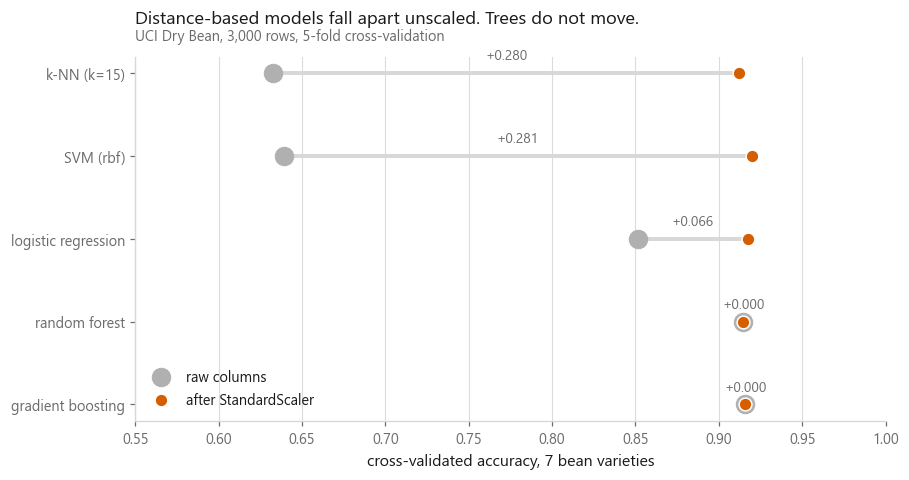

In [5]:
fig, ax = plt.subplots(figsize=(8.8, 4.3))

for i, (name, (raw, scaled)) in enumerate(measured.items()):
    ax.plot([raw, scaled], [i, i], color=style.RULE, lw=2.6, zorder=1)
    # the raw marker is drawn larger so that when the two coincide -- which is
    # what happens for the tree models -- it still shows as a ring underneath.
    ax.scatter(raw, i, s=145, color=style.NEUTRAL, zorder=3,
               label="raw columns" if i == 0 else None)
    ax.scatter(scaled, i, s=70, color=style.HIGHLIGHT, zorder=4,
               edgecolors="white", linewidths=1.0,
               label="after StandardScaler" if i == 0 else None)
    ax.annotate(f"{scaled - raw:+.3f}", xy=((raw + scaled) / 2, i), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9, color=style.MUTED)

ax.set_yticks(list(range(len(measured))), list(measured))
ax.invert_yaxis()
ax.set_xlabel("cross-validated accuracy, 7 bean varieties")
ax.set_xlim(0.55, 1.0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower left")
style.title(ax, "Distance-based models fall apart unscaled. Trees do not move.",
            "UCI Dry Bean, 3,000 rows, 5-fold cross-validation")
style.save(fig, FIG / "fig-01-who-cares.png")

The two tree ensembles print a change of exactly zero. That is not luck, and
it is not rounding. A tree split asks "is this column above this threshold", and
a monotone transform of the column moves the threshold by the same amount it
moves the data. The ordering of the rows is unchanged, so the tree is
unchanged. Any monotone rescaling of any column leaves a tree alone.

k-NN and the support vector machine both lose a large chunk of accuracy,
because both of them are built on a distance and the distance was measuring
bean size only, as section 1 showed.

Logistic regression sits in between, and its failure has a different cause
worth seeing directly.

In [6]:
raw_fit = LogisticRegression(max_iter=1000).fit(X_small, y_small)
scaled_fit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_small, y_small)

print(f"iterations used, raw columns : {raw_fit.n_iter_[0]}  (the cap is 1000)")
print(f"iterations used, scaled      : {scaled_fit[-1].n_iter_[0]}")
print(f"largest coefficient, raw     : {np.abs(raw_fit.coef_).max():.3e}")
print(f"largest coefficient, scaled  : {np.abs(scaled_fit[-1].coef_).max():.3e}")

iterations used, raw columns : 1000  (the cap is 1000)
iterations used, scaled      : 73
largest coefficient, raw     : 1.594e-01
largest coefficient, scaled  : 3.113e+00


The unscaled fit hits the iteration cap and stops early. It did not find a bad
answer so much as run out of budget looking for one. With columns of wildly
different widths the loss surface is a long thin valley, and gradient-based
solvers zig-zag down it slowly. Scaling makes the valley round, and the same
solver finishes in a fraction of the steps.

This is also why the penalty in ridge, lasso and a penalised logistic
regression only makes sense on scaled columns. The penalty charges every
coefficient the same rate, and an unscaled coefficient is large or small for
reasons of units alone.

## 3. The four scalers and outliers

scikit-learn ships four transformers people reach for. Three of them are
affine (they multiply the column by something and add something), and one is
not. That distinction turns out to be the whole story when the column has a
tail.

The `Area` column is a good test. Bombay beans are several times the size of
Dermason beans, so the column has a genuine long right tail rather than a
handful of typos.

In [7]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer, RobustScaler

area = X_bean[["Area"]].values

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "QuantileTransformer": QuantileTransformer(output_distribution="normal",
                                               random_state=SEED),
}

versions = {"raw Area": area.ravel()}
versions.update({name: sc.fit_transform(area).ravel() for name, sc in scalers.items()})

rows = []
for name, values in versions.items():
    q1, med, q3 = np.percentile(values, [25, 50, 75])
    rows.append({
        "column": name,
        "min": values.min(),
        "median": med,
        "max": values.max(),
        "(max - median) / IQR": (values.max() - med) / (q3 - q1),
    })
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:>12,.3f}"))

             column          min       median          max  (max - median) / IQR
           raw Area   20,420.000   44,652.000  254,616.000                 8.397
     StandardScaler       -1.113       -0.286        6.874                 8.397
       MinMaxScaler        0.000        0.103        1.000                 8.397
       RobustScaler       -0.969        0.000        8.397                 8.397
QuantileTransformer       -5.199        0.007        5.199                 3.822


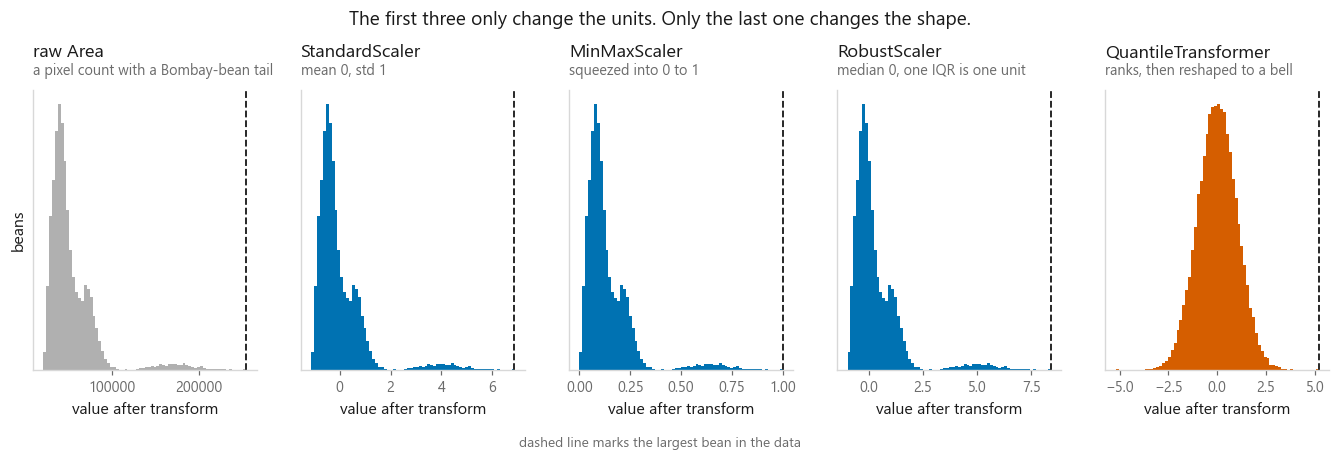

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(15.2, 3.3))

colours = [style.NEUTRAL, style.PALETTE[0], style.PALETTE[0], style.PALETTE[0], style.HIGHLIGHT]
subtitles = ["a pixel count with a Bombay-bean tail",
             "mean 0, std 1",
             "squeezed into 0 to 1",
             "median 0, one IQR is one unit",
             "ranks, then reshaped to a bell"]

for ax, (name, values), colour, sub in zip(axes, versions.items(), colours, subtitles):
    ax.hist(values, bins=70, color=colour)
    ax.axvline(values.max(), color=style.INK, ls="--", lw=1.2)
    ax.set_yticks([])
    ax.set_xlabel("value after transform")
    style.title(ax, name, sub)

axes[0].set_ylabel("beans")
fig.suptitle("The first three only change the units. Only the last one changes the shape.",
             x=0.5, y=1.10, fontsize=12.5, color=style.INK)
fig.text(0.5, -0.10, "dashed line marks the largest bean in the data", ha="center",
         fontsize=9, color=style.MUTED)
style.save(fig, FIG / "fig-02-four-scalers.png")

The first four histograms are the same picture with different numbers on the
x-axis. That is the point of the printed table above: the distance from the
median to the largest bean, measured in interquartile ranges, comes out
identical for the raw column and for all three affine scalers. An affine
transform cannot move a point relative to the rest of the column, so it cannot
do anything about an outlier. It only decides what one unit means.

What the three do differ on is who gets to set that unit.
`StandardScaler` uses the mean and standard deviation, both of which the tail
drags upward. `MinMaxScaler` uses the two extremes, so a single freak value
sets the whole range and the middle of the data gets pressed into a small
corner of the zero-to-one window. `RobustScaler` uses the median and the
interquartile range, so the tail has no vote on the units, which is the
reason to prefer it, and the only reason.

`QuantileTransformer` is the odd one out. It throws away the values and keeps
the ranks, then hands the ranks back as a normal (or uniform) distribution.
The largest bean becomes simply the last bean, and the printed ratio drops
because the tail has been folded in. That is powerful and slightly dangerous:
genuine differences in magnitude are gone, and a test row beyond anything seen
in training gets clipped to the edge.

So which one should you use? I measured that too, with k-NN on the beans.

In [9]:
choices = {"no scaling": None, **scalers}

picks = {}
for name, sc in choices.items():
    model = KNeighborsClassifier(15) if sc is None else make_pipeline(sc, KNeighborsClassifier(15))
    picks[name] = cross_val_score(model, X_small, y_small, cv=folds, n_jobs=-1).mean()
    print(f"{name:22} {picks[name]:.4f}")

scaled_only = {k: v for k, v in picks.items() if k != "no scaling"}
print(f"\nspread across the four scalers : {max(scaled_only.values()) - min(scaled_only.values()):.4f}")
print(f"gap from not scaling at all    : {min(scaled_only.values()) - picks['no scaling']:.4f}")

no scaling             0.6327


StandardScaler         0.9123


MinMaxScaler           0.9090


RobustScaler           0.9157
QuantileTransformer    0.9073

spread across the four scalers : 0.0083
gap from not scaling at all    : 0.2747


The four scalers land within a whisker of each other, and all four are a long
way above doing nothing. **Whether you scale matters enormously. Which
scaler you pick barely matters.** Start with `StandardScaler`, switch to
`RobustScaler` if the column has a tail, and only reach for
`QuantileTransformer` when the shape of the distribution is itself the
problem.

One rule outranks all of this: fit the scaler on the training rows only. A
scaler fitted on everything has seen the test set's mean and range, and your
score goes up for a reason that will not survive contact with new data. Put
the scaler in a `Pipeline` and scikit-learn handles it inside every fold, as
in every cell above.

## 4. Encoding categories, and the ordering you did not mean to invent

Now the other half of the problem. Models take numbers, and some columns are
not numbers.

The Bike Sharing file is a good example of the trap, because it hands you the
categories already converted to integers. `season` arrives as 1, 2, 3, 4.
`weathersit` arrives as 1 to 4. Nothing about the file warns you that these
are labels, so they get fed straight into a model as if they were quantities.

In [10]:
X_bike, y_bike = datasets.bike_sharing()

print(X_bike[["season", "mnth", "weekday", "weathersit", "hr"]].head(3).to_string(index=False))
print("\nmean hourly hires by season code (1 spring, 2 summer, 3 fall, 4 winter)")
print(y_bike.groupby(X_bike["season"]).mean().round(1).to_string())

 season  mnth  weekday  weathersit  hr
      1     1        6           1   0
      1     1        6           1   1
      1     1        6           1   2

mean hourly hires by season code (1 spring, 2 summer, 3 fall, 4 winter)
season
1    111.1
2    208.3
3    236.0
4    198.9


The season effect is real and it is not monotone: hires climb from spring
through fall and then drop back. A model given the raw code has one
coefficient to work with, so it must fit a straight ramp through four points
that do not sit on a line. It cannot represent what is there.

One-hot encoding gives each level its own column, so the model can put each
season wherever the data says it goes.

Here is the part I find most convincing. `season` has four levels, so there
are exactly twenty-four ways to number them, and none of them is more correct
than the others. I fit the ordinal version under all twenty-four numberings.

In [11]:
import itertools

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder

kfold = KFold(5, shuffle=True, random_state=SEED)


def r2_of(matrix):
    return cross_val_score(LinearRegression(), matrix, y_bike.values,
                           cv=kfold, scoring="r2").mean()


levels = sorted(X_bike["season"].unique())
relabellings = list(itertools.permutations(range(len(levels))))
ordinal_scores = [r2_of(X_bike["season"].map(dict(zip(levels, order)))
                        .values.reshape(-1, 1).astype(float))
                  for order in relabellings]

onehot_season = OneHotEncoder(sparse_output=False).fit_transform(X_bike[["season"]])
onehot_score = r2_of(onehot_season)

print(f"ordinal, over all {len(relabellings)} numberings of the four seasons")
print(f"  worst   {min(ordinal_scores):.4f}")
print(f"  best    {max(ordinal_scores):.4f}")
print(f"  average {np.mean(ordinal_scores):.4f}")
print(f"\none-hot, the same for every numbering: {onehot_score:.4f}")
print(f"one-hot beats the best ordinal numbering by {onehot_score - max(ordinal_scores):+.4f}")

ordinal, over all 24 numberings of the four seasons
  worst   -0.0003
  best    0.0555
  average 0.0215

one-hot, the same for every numbering: 0.0653
one-hot beats the best ordinal numbering by +0.0098


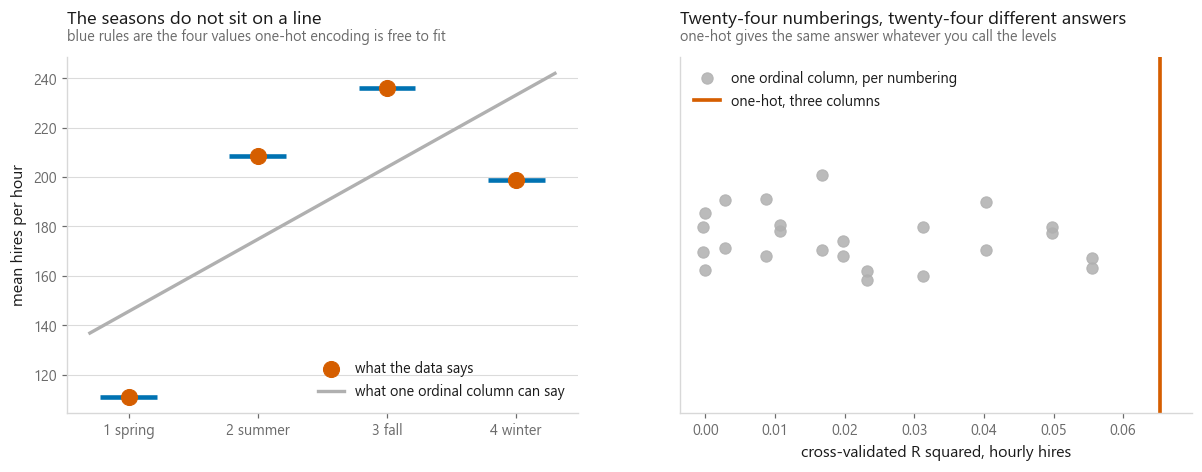

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.2))

# Panel 1: what the ordinal model is forced to draw through the season means
means = y_bike.groupby(X_bike["season"]).mean()
codes = means.index.values.astype(float)
line = LinearRegression().fit(X_bike[["season"]].values.astype(float), y_bike.values)
grid = np.linspace(0.7, 4.3, 50)

axes[0].scatter(codes, means.values, s=110, color=style.HIGHLIGHT, zorder=3,
                marker=style.MARKERS[0], label="what the data says")
axes[0].plot(grid, line.predict(grid.reshape(-1, 1)), color=style.NEUTRAL, lw=2.2,
             label="what one ordinal column can say")
for code, value in zip(codes, means.values):
    axes[0].hlines(value, code - 0.22, code + 0.22, color=style.PALETTE[0], lw=3, zorder=2)
axes[0].set_xticks(codes, ["1 spring", "2 summer", "3 fall", "4 winter"])
axes[0].set_ylabel("mean hires per hour")
axes[0].legend(loc="lower right")
style.title(axes[0], "The seasons do not sit on a line",
            "blue rules are the four values one-hot encoding is free to fit")

# Panel 2: every numbering of the four seasons
jitter = rng.normal(0, 0.055, len(ordinal_scores))
axes[1].scatter(ordinal_scores, jitter, s=55, color=style.NEUTRAL, alpha=0.85,
                label="one ordinal column, per numbering")
axes[1].axvline(onehot_score, color=style.HIGHLIGHT, lw=2.4, label="one-hot, three columns")
axes[1].set_yticks([])
axes[1].set_ylim(-0.35, 0.35)
axes[1].set_xlim(right=onehot_score * 1.07)
axes[1].set_xlabel("cross-validated R squared, hourly hires")
axes[1].legend(loc="upper left")
style.title(axes[1], "Twenty-four numberings, twenty-four different answers",
            "one-hot gives the same answer whatever you call the levels")

style.save(fig, FIG / "fig-03-invented-order.png")

The ordinal score depends entirely on a naming decision that carries no
information. Whoever wrote the CSV chose to call spring 1, and that arbitrary
choice becomes a modelling assumption the moment the column is treated as a
quantity. One-hot encoding is invariant to it, which is the property you want.

The same experiment on the month column is worse, because twelve levels give
far more room to be wrong.

In [13]:
month_levels = sorted(X_bike["mnth"].unique())
shuffled = [r2_of(X_bike["mnth"].map(dict(zip(month_levels, rng.permutation(len(month_levels)))))
                  .values.reshape(-1, 1).astype(float))
            for _ in range(30)]
calendar = r2_of(X_bike[["mnth"]].values.astype(float))
onehot_month = r2_of(OneHotEncoder(sparse_output=False).fit_transform(X_bike[["mnth"]]))

print(f"month in calendar order        : {calendar:.4f}")
print(f"month, 30 random numberings    : worst {min(shuffled):.4f}, best {max(shuffled):.4f}")
print(f"month one-hot (12 columns)     : {onehot_month:.4f}")

month in calendar order        : 0.0142
month, 30 random numberings    : worst -0.0002, best 0.0298
month one-hot (12 columns)     : 0.0739


I expected calendar order to be the best of the ordinal options, since it is
at least the real order. It was not: several random numberings beat it. That
makes sense once you see why: the pattern over the year is a hump, and a
straight line through a hump is close to flat, so any numbering that happens
to split the busy months from the quiet ones scores better than the honest one.
An ordering being real does not make it useful to a linear term.

**Use ordinal encoding only when the order is real and the spacing is roughly
meaningful**: small/medium/large, a rating from one to five, an education
level. Otherwise one-hot.

### Hour of day is a circle

Some columns have an order that is real but wraps around. Hour 23 is one hour
from hour 0, and every encoding above gets that wrong: as a plain number they
are the furthest apart of any pair in the column.

The fix is to place the hour on a circle and hand the model its coordinates.
Two columns, sine and cosine of the angle.

In [14]:
hour = X_bike["hr"].values


def harmonics(k):
    """sin and cos at k cycles per day. k=1 is one hump, k=2 allows two peaks."""
    return np.column_stack([f(2 * np.pi * m * hour / 24)
                            for m in range(1, k + 1) for f in (np.sin, np.cos)])


encodings = {
    "hour as a number": hour.reshape(-1, 1).astype(float),
    "sin and cos (2)": harmonics(1),
    "+ 2nd harmonic (4)": harmonics(2),
    "+ 3rd harmonic (6)": harmonics(3),
    "one-hot (24)": OneHotEncoder(sparse_output=False).fit_transform(hour.reshape(-1, 1)),
}
hour_scores = {name: r2_of(matrix) for name, matrix in encodings.items()}
for name, value in hour_scores.items():
    print(f"{name:20} R squared {value:.4f}")

plain = encodings["hour as a number"]
circle = encodings["sin and cos (2)"]
for name, matrix in [("as a number", plain), ("as sin/cos", circle)]:
    a, b, c = matrix[hour == 23][0], matrix[hour == 0][0], matrix[hour == 12][0]
    print(f"\n{name}: distance 23:00 to 00:00 = {np.linalg.norm(a - b):.3f}"
          f"   |   00:00 to 12:00 = {np.linalg.norm(b - c):.3f}")

hour as a number     R squared 0.1551
sin and cos (2)      R squared 0.3363
+ 2nd harmonic (4)   R squared 0.4111
+ 3rd harmonic (6)   R squared 0.4446
one-hot (24)         R squared 0.5003

as a number: distance 23:00 to 00:00 = 23.000   |   00:00 to 12:00 = 12.000

as sin/cos: distance 23:00 to 00:00 = 0.261   |   00:00 to 12:00 = 2.000


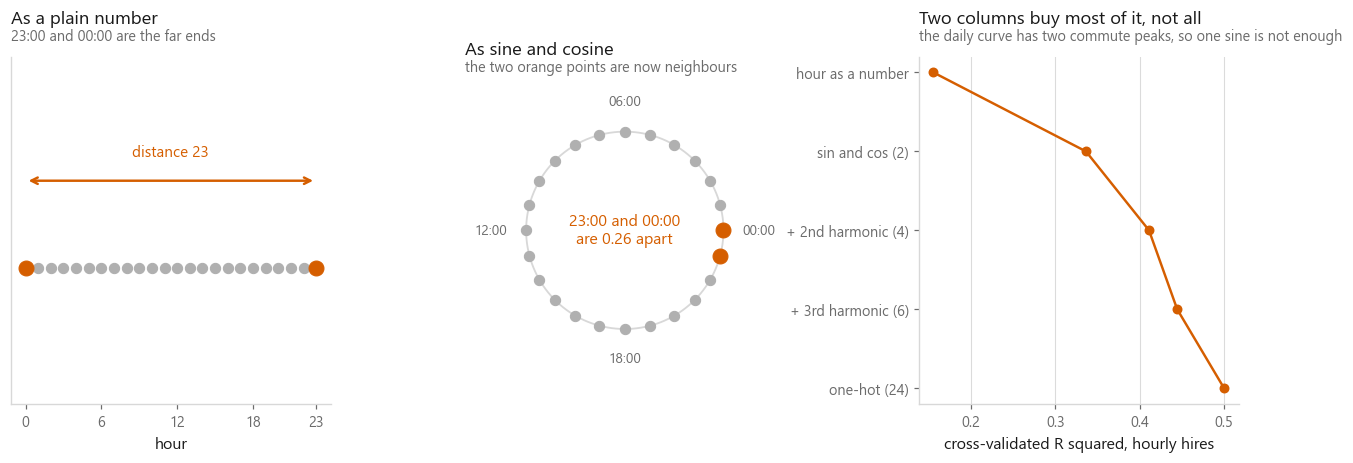

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.1))

# Panel 1: the number line, where midnight and 11pm are as far apart as possible
axes[0].scatter(range(24), np.zeros(24), s=45, color=style.NEUTRAL, zorder=3)
axes[0].scatter([0, 23], [0, 0], s=95, color=style.HIGHLIGHT, zorder=4)
axes[0].annotate("", xy=(0, 0.35), xytext=(23, 0.35),
                 arrowprops=dict(arrowstyle="<->", color=style.HIGHLIGHT, lw=1.6))
axes[0].text(11.5, 0.45, "distance 23", ha="center", color=style.HIGHLIGHT, fontsize=10)
axes[0].set_ylim(-0.55, 0.85)
axes[0].set_yticks([])
axes[0].set_xticks([0, 6, 12, 18, 23])
axes[0].set_xlabel("hour")
axes[0].grid(visible=False)
style.title(axes[0], "As a plain number", "23:00 and 00:00 are the far ends")

# Panel 2: the same hours on a circle
ring = np.linspace(0, 2 * np.pi, 300)
clock = 2 * np.pi * np.arange(24) / 24
axes[1].plot(np.cos(ring), np.sin(ring), color=style.RULE, lw=1.2)
axes[1].scatter(np.cos(clock), np.sin(clock), s=45, color=style.NEUTRAL, zorder=3)
for h in (0, 23):
    axes[1].scatter(np.cos(2 * np.pi * h / 24), np.sin(2 * np.pi * h / 24),
                    s=95, color=style.HIGHLIGHT, zorder=4)
for h in (0, 6, 12, 18):
    axes[1].annotate(f"{h:02d}:00", xy=(1.36 * np.cos(2 * np.pi * h / 24),
                                        1.30 * np.sin(2 * np.pi * h / 24)),
                     ha="center", va="center", fontsize=9, color=style.MUTED)
axes[1].text(0, 0, "23:00 and 00:00\nare 0.26 apart", ha="center", va="center",
             color=style.HIGHLIGHT, fontsize=10.5)
axes[1].set_aspect("equal")
axes[1].set_xlim(-1.62, 1.62)
axes[1].set_ylim(-1.45, 1.45)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].grid(visible=False)
for side in ("left", "bottom"):
    axes[1].spines[side].set_visible(False)
style.title(axes[1], "As sine and cosine", "the two orange points are now neighbours")

# Panel 3: what it is worth
names = list(hour_scores)
axes[2].plot([hour_scores[n] for n in names], list(range(len(names))),
             marker=style.MARKERS[0], color=style.HIGHLIGHT, lw=1.6)
axes[2].set_yticks(list(range(len(names))), names)
axes[2].invert_yaxis()
axes[2].set_xlabel("cross-validated R squared, hourly hires")
axes[2].grid(axis="y", visible=False)
axes[2].grid(axis="x", visible=True)
style.title(axes[2], "Two columns buy most of it, not all",
            "the daily curve has two commute peaks, so one sine is not enough")

fig.subplots_adjust(wspace=0.42)
style.save(fig, FIG / "fig-04-hours-on-a-circle.png")

The distance printout is the whole idea in two numbers. Under sine and cosine,
23:00 and midnight sit next to each other and midnight and noon sit opposite.
That is the geometry the clock actually has.

The score column carries the honest caveat. Sine and cosine at one cycle per
day lift the score well above what the raw hour number manages, and the
[linear regression notebook](../../02-regression/01-linear-regression/) already
showed the same trick lifting R squared sharply on this dataset with the full
feature set. But one-hot over every hour still wins here, because Washington's
bike demand has a morning peak and an evening peak, and a single sine wave has
only one hump. Adding the second and third harmonics closes most of the gap
with far fewer columns.

Use sine and cosine when you need few columns, when the levels are many (day
of year has 365), or when a tree-free model has to extrapolate smoothly. Use
one-hot when the number of levels is small and the shape is lumpy.

## 5. Target encoding and its leak

One-hot stops being reasonable somewhere around a few dozen levels. A column
with thousands of levels (a postcode, a product code, a user id) turns into
a matrix wider than it is tall.

**Target encoding** replaces the category with the mean of the target for that
category. One column, any cardinality. To have something real to test on I
build the weekly time slot: day of week crossed with hour, so one level per
recurring moment in the week.

In [16]:
from sklearn.linear_model import Ridge

frame = X_bike.copy()
frame["slot"] = (frame["weekday"] * 24 + frame["hr"]).astype(str)
numeric = ["temp", "hum", "windspeed", "yr", "workingday"]

train, test, y_train, y_test = train_test_split(frame, y_bike, test_size=0.3, random_state=SEED)
train, test = train.reset_index(drop=True), test.reset_index(drop=True)
y_train, y_test = y_train.reset_index(drop=True), y_test.reset_index(drop=True)

print(f"weekly slots: {frame['slot'].nunique()} levels, "
      f"{len(train) / frame['slot'].nunique():.0f} training rows each")


def encode_leaky(column_train, target_train, column_test):
    """The tempting version: one mean per category, computed on all training rows."""
    means, overall = target_train.groupby(column_train).mean(), target_train.mean()
    return (column_train.map(means).fillna(overall).values,
            column_test.map(means).fillna(overall).values)


def encode_out_of_fold(column_train, target_train, column_test, splitter):
    """The safe version: each row is encoded using folds that did not contain it."""
    overall = target_train.mean()
    encoded = np.full(len(column_train), overall)
    for inner, held_out in splitter.split(column_train):
        means = target_train.iloc[inner].groupby(column_train.iloc[inner]).mean()
        encoded[held_out] = column_train.iloc[held_out].map(means).fillna(overall).values
    full = target_train.groupby(column_train).mean()
    return encoded, column_test.map(full).fillna(overall).values


def cv_and_test(matrix_train, matrix_test):
    cv = cross_val_score(Ridge(), matrix_train, y_train.values, cv=kfold, scoring="r2").mean()
    return cv, Ridge().fit(matrix_train, y_train.values).score(matrix_test, y_test.values)


slot_results = {}
slot_results["weather only"] = cv_and_test(train[numeric].values, test[numeric].values)

from sklearn.compose import ColumnTransformer

wide = make_pipeline(
    ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), ["slot"]),
                       ("num", "passthrough", numeric)]),
    Ridge())
slot_results["one-hot, 168 columns"] = (
    cross_val_score(wide, train, y_train.values, cv=kfold, scoring="r2").mean(),
    wide.fit(train, y_train.values).score(test, y_test.values))

a, b = encode_leaky(train["slot"], y_train, test["slot"])
slot_results["target enc, leaky"] = cv_and_test(np.c_[train[numeric].values, a],
                                                np.c_[test[numeric].values, b])
a, b = encode_out_of_fold(train["slot"], y_train, test["slot"], kfold)
slot_results["target enc, out of fold"] = cv_and_test(np.c_[train[numeric].values, a],
                                                      np.c_[test[numeric].values, b])

for name, (cv, held) in slot_results.items():
    print(f"{name:26} CV {cv:.4f}   held-out test {held:.4f}   gap {cv - held:+.4f}")

weekly slots: 168 levels, 72 training rows each


weather only               CV 0.2894   held-out test 0.3094   gap -0.0200
one-hot, 168 columns       CV 0.7802   held-out test 0.7859   gap -0.0057
target enc, leaky          CV 0.7802   held-out test 0.7779   gap +0.0022
target enc, out of fold    CV 0.7736   held-out test 0.7780   gap -0.0044


When every level has plenty of rows, target encoding matches one-hot and does
it in a single column instead of one per level. That is the reason to use it.

The leaky version also looks fine here, which is exactly what makes the
mistake so easy to keep. Encoding a category using the mean of a group that
includes the row being encoded puts a little of that row's own target into its
features. When many rows share a level the contamination is diluted away. When
only a handful do, it is most of the answer.

To measure it cleanly I add a column that is pure noise (a random ticket
number, related to nothing) and vary how many rows share a number.

In [17]:
sweep = []
for per_category in [2, 4, 8, 20, 60, 200]:
    n_levels = max(len(train) // per_category, 1)
    train["ticket"] = rng.integers(0, n_levels, len(train)).astype(str)
    test["ticket"] = rng.integers(0, n_levels, len(test)).astype(str)

    a, b = encode_leaky(train["ticket"], y_train, test["ticket"])
    leaky_cv, leaky_test = cv_and_test(np.c_[train[numeric].values, a],
                                       np.c_[test[numeric].values, b])
    c, d = encode_out_of_fold(train["ticket"], y_train, test["ticket"], kfold)
    safe_cv, safe_test = cv_and_test(np.c_[train[numeric].values, c],
                                     np.c_[test[numeric].values, d])

    sweep.append({"rows per level": per_category, "levels": n_levels,
                  "leaky CV": leaky_cv, "leaky test": leaky_test,
                  "out-of-fold CV": safe_cv,
                  "inflation": leaky_cv - leaky_test,
                  "corr with target, leaky": np.corrcoef(a, y_train.values)[0, 1],
                  "corr with target, safe": np.corrcoef(c, y_train.values)[0, 1]})

sweep = pd.DataFrame(sweep)
print(sweep.to_string(index=False, float_format=lambda v: f"{v:>10,.4f}"))
print(f"\nweather-only baseline: CV {slot_results['weather only'][0]:.4f}, "
      f"test {slot_results['weather only'][1]:.4f}")

 rows per level  levels   leaky CV  leaky test  out-of-fold CV  inflation  corr with target, leaky  corr with target, safe
              2    6082     0.5395     -0.0415          0.2893     0.5810                   0.6575                 -0.0029
              4    3041     0.4203      0.1036          0.2891     0.3166                   0.4935                 -0.0137
              8    1520     0.3509      0.2327          0.2893     0.1182                   0.3544                  0.0023
             20     608     0.3157      0.2794          0.2893     0.0364                   0.2157                 -0.0091
             60     202     0.2957      0.3021          0.2895    -0.0064                   0.1238                 -0.0057
            200      60     0.2920      0.3090          0.2894    -0.0170                   0.0734                  0.0090

weather-only baseline: CV 0.2894, test 0.3094


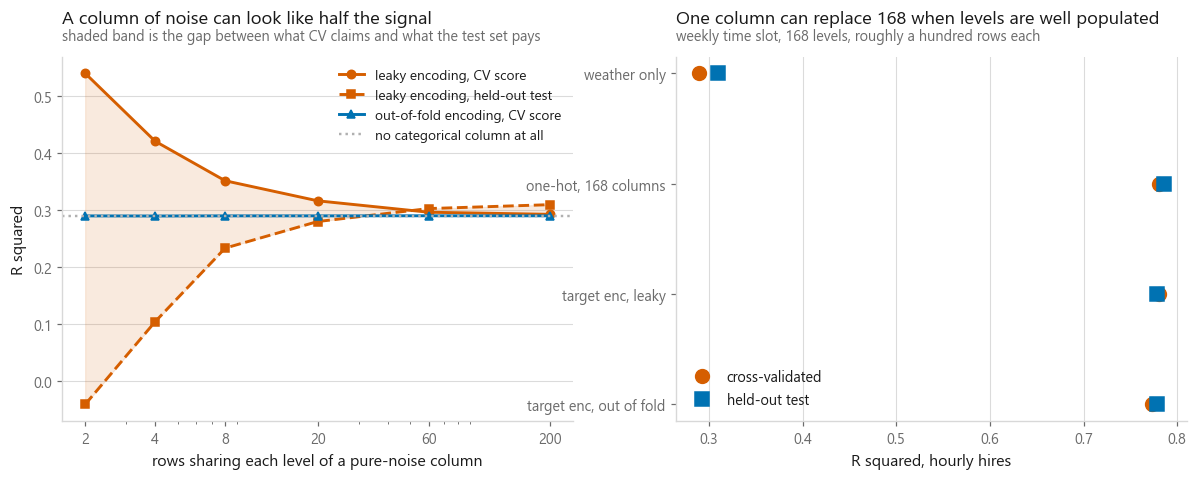

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.3))

axes[0].fill_between(sweep["rows per level"], sweep["leaky CV"], sweep["leaky test"],
                     color=style.HIGHLIGHT, alpha=0.13)
axes[0].plot(sweep["rows per level"], sweep["leaky CV"], marker=style.MARKERS[0],
             color=style.HIGHLIGHT, label="leaky encoding, CV score")
axes[0].plot(sweep["rows per level"], sweep["leaky test"], marker=style.MARKERS[1],
             color=style.HIGHLIGHT, ls="--", label="leaky encoding, held-out test")
axes[0].plot(sweep["rows per level"], sweep["out-of-fold CV"], marker=style.MARKERS[2],
             color=style.PALETTE[0], label="out-of-fold encoding, CV score")
axes[0].axhline(slot_results["weather only"][0], color=style.NEUTRAL, ls=":", lw=1.6,
                label="no categorical column at all")
axes[0].set_xscale("log")
axes[0].set_xticks(sweep["rows per level"], [str(v) for v in sweep["rows per level"]])
axes[0].set_xlabel("rows sharing each level of a pure-noise column")
axes[0].set_ylabel("R squared")
axes[0].legend(loc="upper right", fontsize=9)
style.title(axes[0], "A column of noise can look like half the signal",
            "shaded band is the gap between what CV claims and what the test set pays")

names = list(slot_results)
rank = list(range(len(names)))
axes[1].plot([slot_results[n][0] for n in names], rank,
             marker=style.MARKERS[0], ls="none", ms=9, color=style.HIGHLIGHT,
             label="cross-validated")
axes[1].plot([slot_results[n][1] for n in names], rank,
             marker=style.MARKERS[1], ls="none", ms=9, color=style.PALETTE[0],
             label="held-out test")
axes[1].set_yticks(rank, names)
axes[1].invert_yaxis()
axes[1].set_xlabel("R squared, hourly hires")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
axes[1].legend(loc="lower left")
style.title(axes[1], "One column can replace 168 when levels are well populated",
            "weekly time slot, 168 levels, roughly a hundred rows each")

style.save(fig, FIG / "fig-05-target-leak.png")

At the sparse end of the sweep, the leaky encoding of a column containing no
information at all reports a cross-validated score far above the baseline, and
the held-out test set pays nothing back: it comes in below the model that
never saw the column. The correlation column in the table shows the mechanism:
the leaky encoding is strongly correlated with the target it was built from,
while the out-of-fold encoding is correlated with it at the level of chance,
which is the correct answer for random noise.

The out-of-fold line is flat across the whole sweep. It sits on the baseline
no matter how rare the categories get, because a row's encoding never saw that
row's target.

scikit-learn's `TargetEncoder` does this cross-fitting internally during
`fit_transform`, and also shrinks small categories toward the overall mean, so
putting it inside a `Pipeline` gets you both protections. Writing it out by
hand once is worth it, because the same shape of mistake appears anywhere a
feature is computed from the target: count encodings, frequency encodings,
out-of-time aggregates, anything with the word "historical average" in it.

## Cheat sheet

| | |
|---|---|
| **Scale for** | k-NN, SVM, PCA, k-means, neural nets, and any penalised linear model. Anything using a distance or a gradient |
| **Do not bother for** | Decision trees, random forests, gradient boosting. Splits are invariant to monotone transforms |
| **Default scaler** | `StandardScaler`. Which scaler you choose matters far less than choosing one |
| **Long tail** | `RobustScaler`: median and IQR set the units, so the tail does not. It does not remove the outlier, nothing affine can |
| **Reshape the column** | `QuantileTransformer`, the only one of the four that changes the distribution rather than the units |
| **Always** | Fit the scaler inside a `Pipeline` so it never sees the validation fold |
| **Unordered categories** | One-hot. Invariant to how the levels were numbered |
| **Ordered categories** | Ordinal, with codes you chose on purpose and spacing that means something |
| **Cyclical** | Sine and cosine of the angle. Add harmonics if the daily shape has more than one peak |
| **High cardinality** | Target encoding, computed out of fold, `TargetEncoder` inside a `Pipeline` |
| **Next** | [Missing data](../08-missing-data/), which is the other thing that stops a raw table from being a matrix |

## What to remember

1. Unscaled distances are decided by whichever column has the largest units,
   not by whichever column carries the signal.
2. Trees do not care, and the change is zero rather than small. Distance and
   gradient methods care a great deal.
3. `StandardScaler`, `MinMaxScaler` and `RobustScaler` are affine. They choose
   the units and cannot move an outlier relative to the rest of the column.
   `QuantileTransformer` can, because it keeps only the ranks.
4. Ordinal encoding of unordered categories smuggles in an ordering that came
   from whoever wrote the CSV. One-hot gives the same answer whatever the
   levels were called.
5. A real ordering is not automatically a useful one: calendar month order
   lost to random numberings here, because the yearly pattern is a hump.
6. Cyclical columns need sine and cosine, or the two ends of the cycle end up
   as far apart as the encoding allows.
7. Target encoding computed on all the training rows leaks the target into the
   features. The damage scales with how few rows share a level, and it shows up
   as a cross-validation score the test set will not honour.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-08 Missing data](../08-missing-data/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#FeatureEngineering` `#DataPreprocessing` `#ScikitLearn`
`#OneHotEncoding` `#TargetEncoding` `#DataLeakage` `#Python` `#DataScience`
`#MLTutorial`